In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

In [45]:
#df=df_data_1.copy()

In [46]:
df=pd.read_csv("placement.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,NaN
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  196 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [48]:
df.describe()

,cgpa,package
count,200.000000,196.000000
mean,6.990500,2.995561
std,1.069409,0.693068
min,4.260000,1.370000
25%,6.190000,2.505000
50%,6.965000,2.995000
75%,7.737500,3.490000
max,9.580000,4.620000


In [49]:
df.isnull().sum()

cgpa       0
package    4
dtype: int64

In [50]:
df.fillna(df.mean())

,cgpa,package
0,6.89,3.260000
1,5.12,1.980000
2,7.82,3.250000
3,7.42,2.995561
4,6.94,3.570000
...,...,...
195,6.93,2.460000
196,5.89,2.570000
197,7.21,3.240000
198,7.63,3.960000


Text(0, 0.5, 'Package(in lpa)')

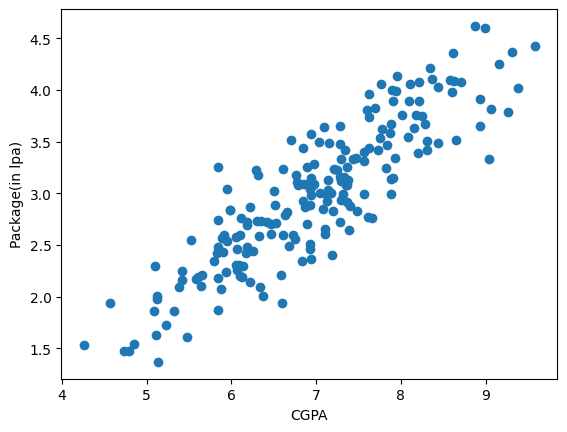

In [51]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [52]:
imputer = SimpleImputer(strategy='mean')
data_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [53]:
data_filled

,cgpa,package
0,6.89,3.260000
1,5.12,1.980000
2,7.82,3.250000
3,7.42,2.995561
4,6.94,3.570000
...,...,...
195,6.93,2.460000
196,5.89,2.570000
197,7.21,3.240000
198,7.63,3.960000


In [54]:
X = data_filled.iloc[:,0:1]
y = data_filled.iloc[:,-1]

In [55]:
y

0      3.260000
1      1.980000
2      3.250000
3      2.995561
4      3.570000
         ...   
195    2.460000
196    2.570000
197    3.240000
198    3.960000
199    2.995561
Name: package, Length: 200, dtype: float64

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [57]:
lr = LinearRegression()

In [58]:
lr.fit(X_train,y_train)

LinearRegression()

In [59]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [60]:
y_test


112    4.100000
29     3.490000
182    2.080000
199    2.995561
193    1.940000
85     1.480000
10     1.860000
54     3.090000
115    4.210000
35     2.870000
12     3.650000
92     4.000000
13     2.890000
126    2.600000
174    2.990000
2      3.250000
44     1.860000
3      2.995561
113    2.370000
14     3.420000
23     2.480000
25     3.650000
6      2.600000
134    2.830000
165    4.080000
173    2.560000
45     3.580000
65     3.810000
48     4.090000
122    2.010000
178    3.630000
64     2.920000
9      3.510000
57     1.940000
78     2.210000
71     3.340000
128    3.340000
176    3.230000
131    2.010000
53     2.610000
Name: package, dtype: float64

In [61]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\kesha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.88343531])

In [62]:
y_pred=lr.predict(X_test)

Text(0, 0.5, 'Package(in lpa)')

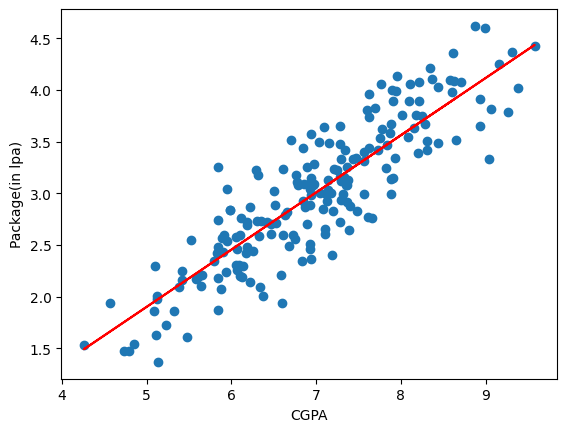

In [63]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [71]:
m = lr.coef_
m

array([0.55347088])

In [65]:
b = lr.intercept_
print(b)

-0.865344860717776


In [66]:
# y = mx + b

m * 8.58 + b

array([3.88343531])

In [67]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test,y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 0.29


In [68]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test,y_pred)
print(f"Mean Squared Error: {mse:.2f}")



Mean Squared Error: 0.12
